<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter2/exact_pendulum_period.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Period T of the simple pendulum: Exact vs small angle and oscillation and rotation cases

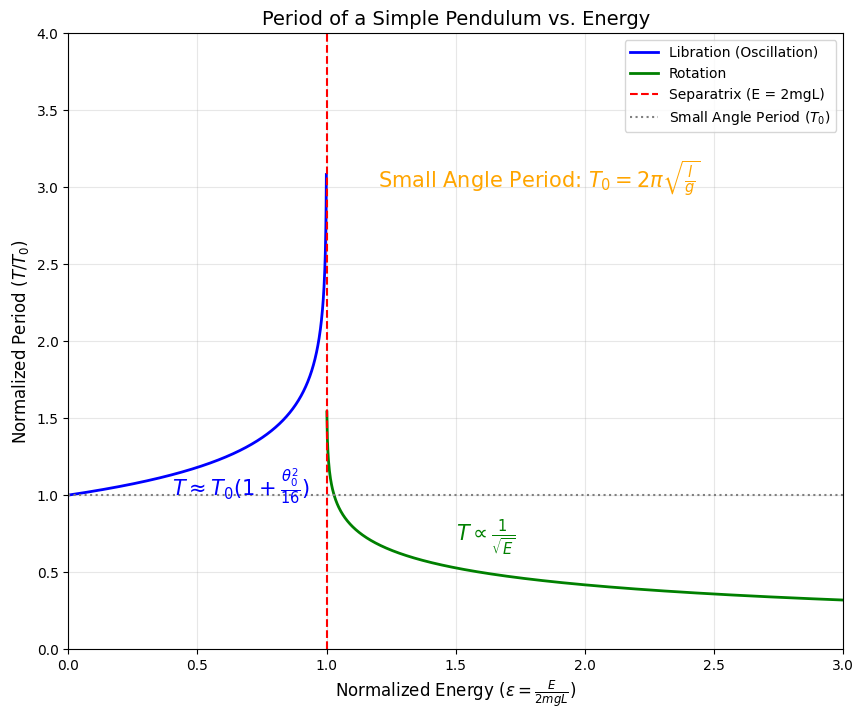

Plot generated: pendulum_period_energy.png


<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk

def plot_pendulum_period():
    # Define normalized energy: epsilon = E / (2mgL)
    # epsilon < 1: Libration
    # epsilon = 1: Separatrix
    # epsilon > 1: Rotation

    # --- 1. LIBRATION REGIME (Oscillation) ---
    # epsilon goes from 0 to just under 1
    eps_lib = np.linspace(0, 0.999, 1000)

    # Formula: T/T0 = (2/pi) * K(k^2)
    # where k^2 = epsilon
    # scipy.special.ellipk takes m = k^2 as input
    T_lib = (2 / np.pi) * ellipk(eps_lib)

    # --- 2. ROTATION REGIME (Spinning) ---
    # epsilon goes from just over 1 to higher energy (e.g., 3)
    eps_rot = np.linspace(1.001, 3.0, 1000)

    # Formula: T/T0 = (1 / (pi * sqrt(epsilon))) * K(1/epsilon)
    # The modulus m for ellipk is 1/epsilon
    T_rot = (1 / (np.pi * np.sqrt(eps_rot))) * ellipk(1/eps_rot)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 8))

    # Plot Libration
    plt.plot(eps_lib, T_lib, label='Libration (Oscillation)', color='blue', linewidth=2)

    # Plot Rotation
    plt.plot(eps_rot, T_rot, label='Rotation', color='green', linewidth=2)

    # Plot Separatrix Asymptote
    plt.axvline(x=1.0, color='red', linestyle='--', label='Separatrix (E = 2mgL)')

    # Plot T0 Reference (Small Angle approximation)
    plt.axhline(y=1.0, color='gray', linestyle=':', label='Small Angle Period ($T_0$)')

    # Styling
    plt.title('Period of a Simple Pendulum vs. Energy', fontsize=14)
    plt.xlabel(r'Normalized Energy ($\epsilon = \frac{E}{2mgL}$)', fontsize=12)
    plt.ylabel(r'Normalized Period ($T / T_0$)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 4) # Limit y-axis to see the curves clearly (asymptote goes to infinity)
    plt.xlim(0, 3)

    # Annotations
    plt.text(1.2,3.0,r'Small Angle Period: $T_0=2\pi\sqrt{\frac{l}{g}}$',color='orange', fontsize=15)
    plt.text(0.4, 1.0, r'$T \approx T_0 (1 + \frac{\theta_0^2}{16})$', color='blue', fontsize=15)
    plt.text(1.5, 0.7, r'$T \propto \frac{1}{\sqrt{E}}$', color='green', fontsize=15)
    plt.show()
    plt.savefig('pendulum_period_energy.png', dpi=300)
    print("Plot generated: pendulum_period_energy.png")

if __name__ == "__main__":
    plot_pendulum_period()